In [1]:
import numpy as np
import pandas as pd
import statistics

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

plt.style.use('default')
sns.set_palette("husl")
SEED = 43
np.random.seed(SEED)


In [2]:
data = pd.read_csv("../data/data2.csv", index_col=0)
print(data)

           country time_of_day        lat       long      road_type  \
Unnamed: 0                                                            
8459            SE         day  55.604209  13.028574           city   
71801           IT         day  41.987014  12.496538        highway   
90649           DE         day  49.182153   9.414737        highway   
48806           SE         day  55.576732  13.013051           city   
35874           IT         day  45.478483   9.200364           city   
...            ...         ...        ...        ...            ...   
11242           SE         day  55.598127  12.975875           city   
90673           PL         day  50.253217  19.823732  smaller-rural   
24373           DE         day  50.931399   6.953686           city   
41597           SE         day  55.608149  13.003458           city   
40353           IT       night  41.918667  12.383545           city   

           road_condition            weather  solar_angle_elevation  month  

In [3]:
all_columns = data.columns    

print(f"Number of rows: {data.shape[0]}")
print(f"Columns: {all_columns}")
print(f"Number of columns: {len(all_columns)}")

Number of rows: 5998
Columns: Index(['country', 'time_of_day', 'lat', 'long', 'road_type', 'road_condition',
       'weather', 'solar_angle_elevation', 'month', 'hour',
       'forward_acceleration', 'lateral_acceleration', 'forward_velocity',
       'lateral_velocity', 'field_view_horizontal',
       'camera_distance_from_ground', 'camera_pitch_angle',
       'distortion_magnitude', 'camera_offset', 'laplacian', 'quality',
       'brightness', 'noisiness', 'sharpness', 'contrast', 'complexity',
       'conf', 'iou', 'lrp', 'temperature_2m', 'relative_humidity_2m', 'rain',
       'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'wind_speed_10m', 'weather_code'],
      dtype='object')
Number of columns: 38


In [4]:
numeric_columns = ['lat', 'long', 'solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'rain', 'snowfall',
       'forward_acceleration', 'lateral_acceleration', 'forward_velocity',
       'lateral_velocity', 'field_view_horizontal',
       'camera_distance_from_ground', 'camera_pitch_angle',
       'distortion_magnitude', 'camera_offset', 
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 
       'wind_speed_10m', 'conf',  'laplacian', 'quality', 'brightness', 'noisiness', 'sharpness', 'contrast', 'complexity', 
       'iou', 'lrp']

categorical_columns = ['time_of_day', 'country', 'road_type', 'road_condition',
       'weather', 'weather_code']

print(intersection := set(all_columns) - set(numeric_columns) - set(categorical_columns))
assert len(all_columns) == (len(categorical_columns) + len(numeric_columns)), "Columns not match"


set()


# EDA

## Dataset Representativeness and Bias

### Categorical Variables

In [5]:
print(f"Number of categorical features: {len(categorical_columns)}")
for col in categorical_columns:
    print("-" * 10)
    print(f"Column: {col}")
    print(f"Unique values: {data[col].nunique()}")
    print(f"Most common: {data[col].mode().iloc[0] if not data[col].mode().empty else 'N/A'}")
    print(f"Missing values: {data[col].isnull().sum()}")

Number of categorical features: 6
----------
Column: time_of_day
Unique values: 3
Most common: day
Missing values: 0
----------
Column: country
Unique values: 9
Most common: SE
Missing values: 0
----------
Column: road_type
Unique values: 5
Most common: city
Missing values: 0
----------
Column: road_condition
Unique values: 3
Most common: normal
Missing values: 0
----------
Column: weather
Unique values: 9
Most common: partly-cloudy-day
Missing values: 0
----------
Column: weather_code
Unique values: 11
Most common: 3.0
Missing values: 13


Distribution

In absolute values:

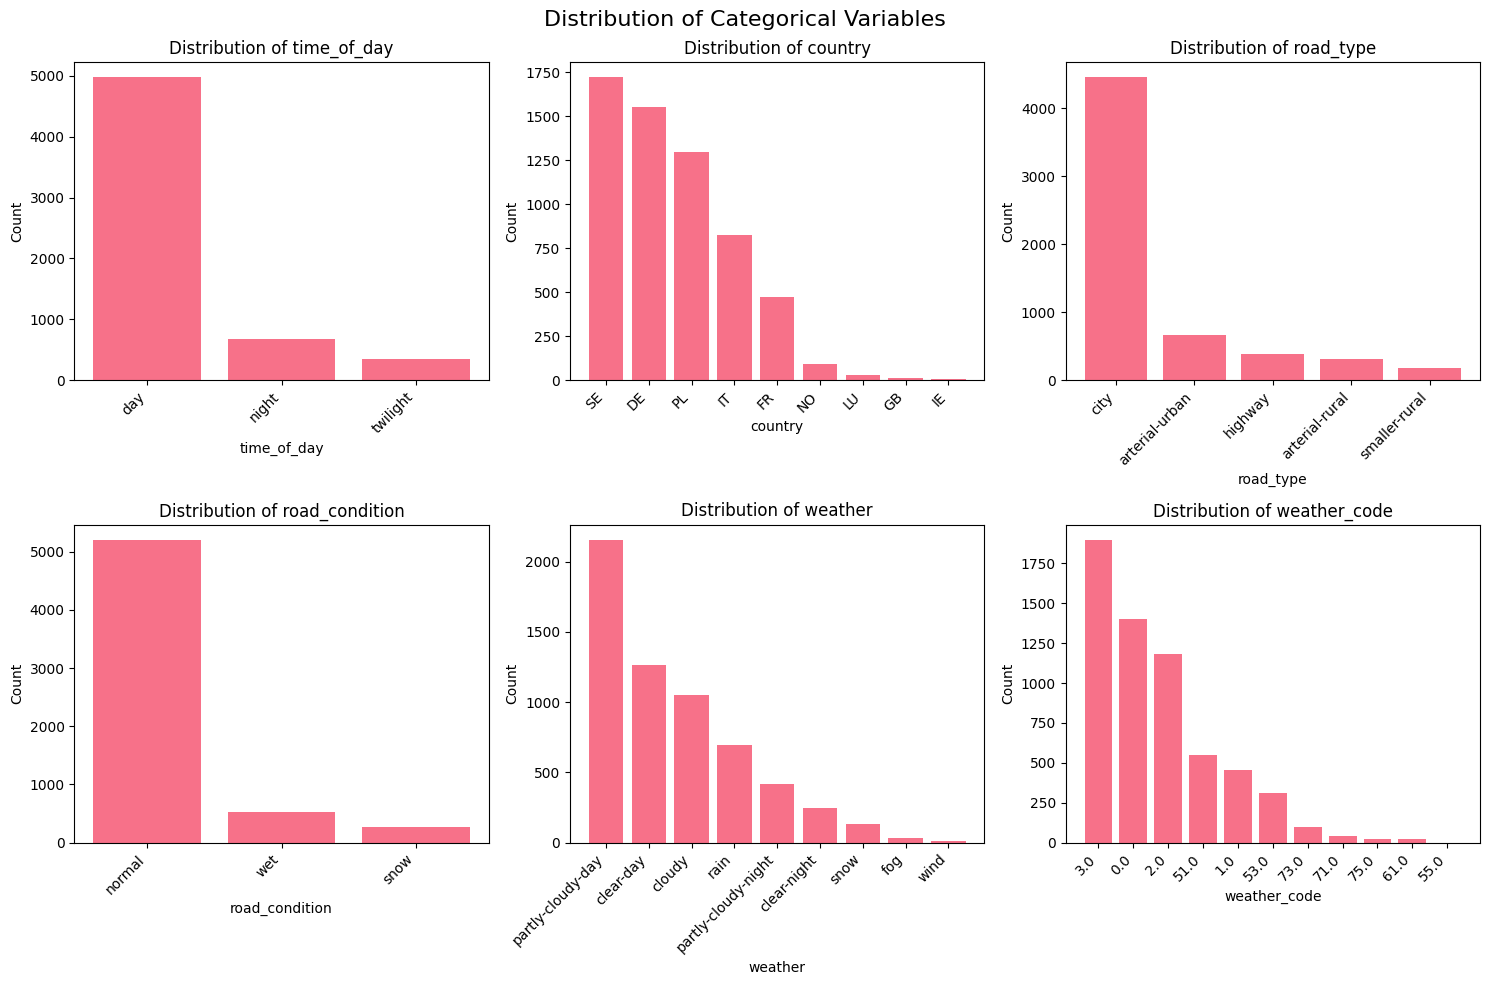

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16)

axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    value_counts = data[column].value_counts()
    axes[i].bar(range(len(value_counts)), value_counts.values)
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    
    axes[i].set_xticks(range(len(value_counts)))
    axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')


plt.tight_layout()
plt.savefig("./plots/categorical_distributions.png")
plt.show()

In percentage values:

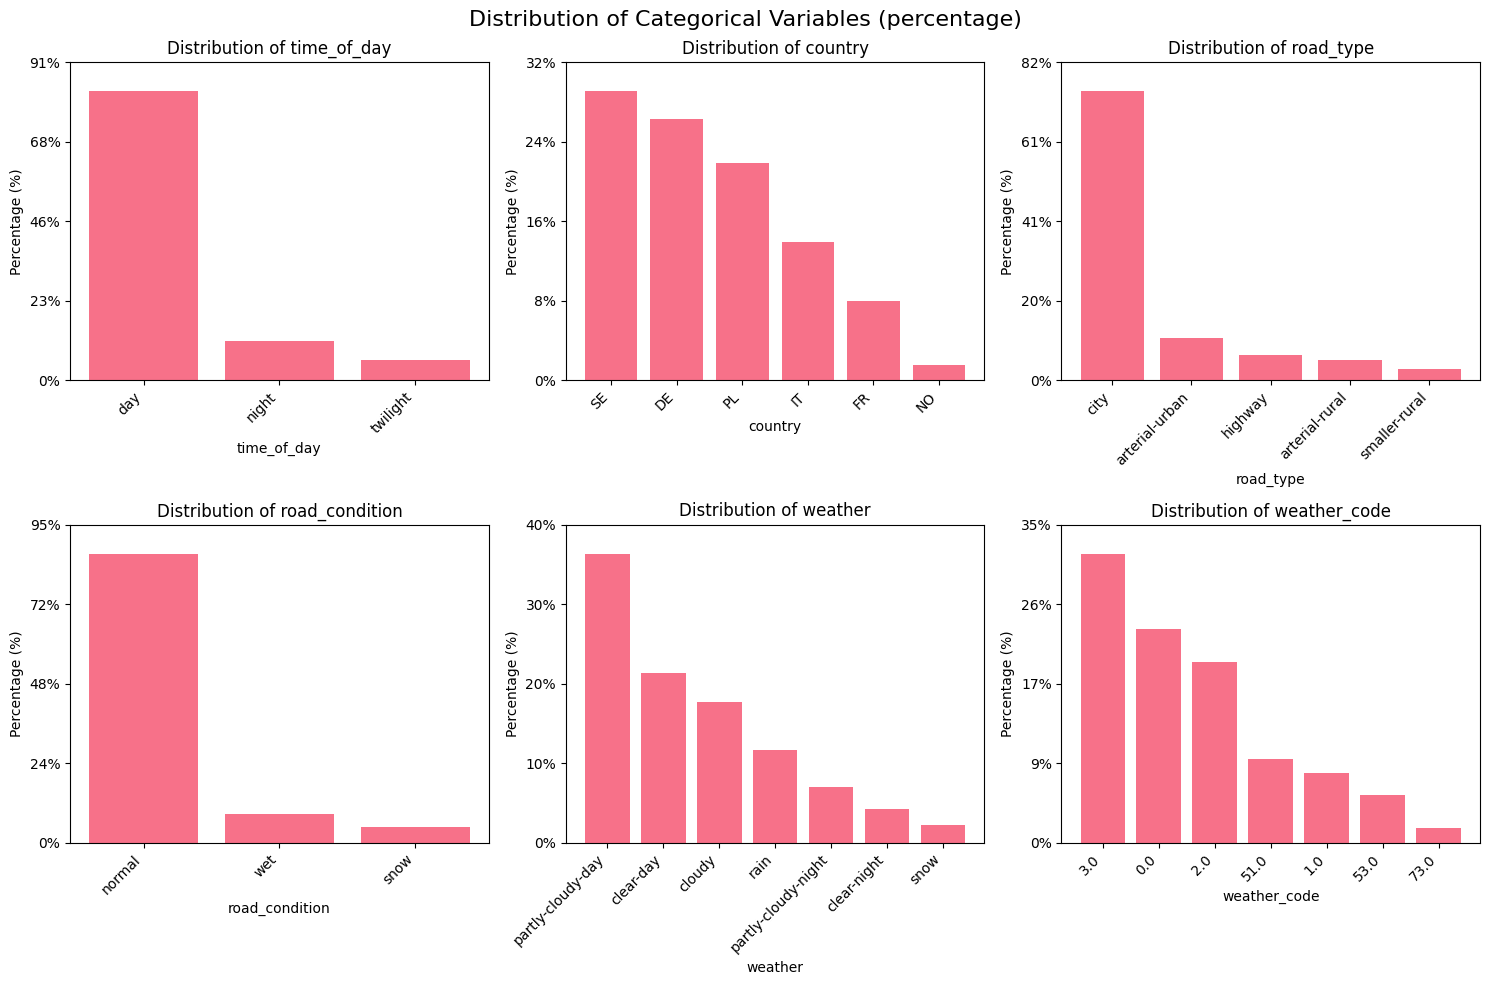

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Variables (percentage)', fontsize=16)

axes = axes.flatten()

cat_dist_percentages = {}
for i, column in enumerate(categorical_columns):
    value_counts = data[column].value_counts()
    total_counts = value_counts.sum()
    # keep only categories >= 1% of total
    value_counts = value_counts[value_counts / total_counts >= 0.01]
    percentages = value_counts / total_counts * 100
    cat_dist_percentages[column] = percentages

    axes[i].bar(range(len(percentages)), percentages.values)
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Percentage (%)')
    
    axes[i].set_xticks(range(len(percentages)))
    axes[i].set_xticklabels(percentages.index, rotation=45, ha='right')

    # format y ticks as percentages
    ylim_top = max(percentages.max() * 1.1, 5)
    axes[i].set_ylim(0, ylim_top)
    yticks = np.linspace(0, ylim_top, 5)
    axes[i].set_yticks(yticks)
    axes[i].set_yticklabels([f'{t:.0f}%' for t in yticks])

plt.tight_layout()
plt.savefig("./plots/categorical_distributions_percent.png")
plt.show()

Underrepresented Categorical Values:

In [8]:
threshold = 5.0
print(f"Categorical categories with <= {threshold}% representation:")
for col, percentages in cat_dist_percentages.items():
    low = percentages[percentages <= threshold]
    if not low.empty:
        print("-" * 10)
        print(f"Column: {col}")
        print(low)

Categorical categories with <= 5.0% representation:
----------
Column: country
country
NO    1.550517
Name: count, dtype: float64
----------
Column: road_type
road_type
smaller-rural    3.001
Name: count, dtype: float64
----------
Column: road_condition
road_condition
snow    4.601534
Name: count, dtype: float64
----------
Column: weather
weather
clear-night    4.151384
snow           2.234078
Name: count, dtype: float64
----------
Column: weather_code
weather_code
73.0    1.654135
Name: count, dtype: float64


Compounding sparsity

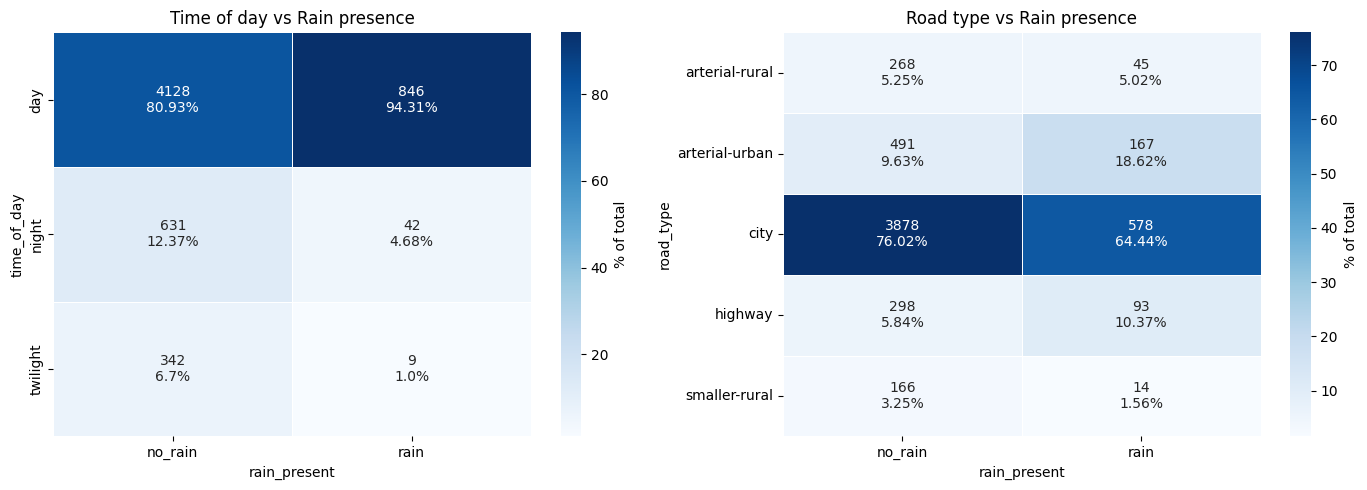

In [17]:
rain_present = data["rain"].fillna(0) > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ctab1 = pd.crosstab(data["time_of_day"], rain_present)
ctab1.columns = [f"no_rain", f"rain"]
ctab1["total"] = ctab1.sum(axis=1)
ctab1.loc["Total"] = ctab1.sum(axis=0)

ctab1_pct = (ctab1.loc[ctab1.index != "Total", [f"no_rain", f"rain"]] /
             ctab1.loc["Total", [f"no_rain", f"rain"]]) * 100

annot1 = (ctab1.loc[ctab1.index != "Total", [f"no_rain", f"rain"]].astype(int).astype(str)
          + "\n"
          + ctab1_pct.round(2).astype(str) + "%")

sns.heatmap(ctab1_pct.astype(float), annot=annot1, fmt="", cmap="Blues",
            cbar_kws={"label": "% of total"}, linewidths=0.5, linecolor="white",
            ax=axes[0])
axes[0].set_title(f"Time of day vs Rain presence")
axes[0].set_ylabel("time_of_day")
axes[0].set_xlabel(f"rain_present")

ctab2 = pd.crosstab(data["road_type"], rain_present)
ctab2.columns = [f"no_rain", f"rain"]
ctab2["total"] = ctab2.sum(axis=1)
ctab2.loc["Total"] = ctab2.sum(axis=0)

ctab2_pct = (ctab2.loc[ctab2.index != "Total", [f"no_rain", f"rain"]] /
             ctab2.loc["Total", [f"no_rain", f"rain"]]) * 100

annot2 = (ctab2.loc[ctab2.index != "Total", [f"no_rain", f"rain"]].astype(int).astype(str)
          + "\n"
          + ctab2_pct.round(2).astype(str) + "%")

sns.heatmap(ctab2_pct.astype(float), annot=annot2, fmt="", cmap="Blues",
            cbar_kws={"label": "% of total"}, linewidths=0.5, linecolor="white",
            ax=axes[1])
axes[1].set_title(f"Road type vs Rain presence")
axes[1].set_ylabel("road_type")
axes[1].set_xlabel(f"rain_present")

plt.tight_layout()
plt.savefig(f"./plots/combined_rain_sparsity.png")
plt.show()

Correlation - Using Pearson and labels encoded

In [ ]:

encoded_data = data[categorical_columns].copy()
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    if column == 'weather_code':
        continue
    encoded_data[column] = encoded_data[column].fillna('Unknown')
    encoded_data[column] = le.fit_transform(encoded_data[column])
    label_encoders[column] = le

pearson_corr = encoded_data.corr()
print(pearson_corr.round(3))

                time_of_day  country  road_type  road_condition  weather  \
time_of_day           1.000   -0.197      0.043          -0.015    0.212   
country              -0.197    1.000     -0.030           0.119   -0.028   
road_type             0.043   -0.030      1.000          -0.082   -0.076   
road_condition       -0.015    0.119     -0.082           1.000    0.322   
weather               0.212   -0.028     -0.076           0.322    1.000   
weather_code         -0.088    0.041     -0.065           0.490    0.425   

                weather_code  
time_of_day           -0.088  
country                0.041  
road_type             -0.065  
road_condition         0.490  
weather                0.425  
weather_code           1.000  


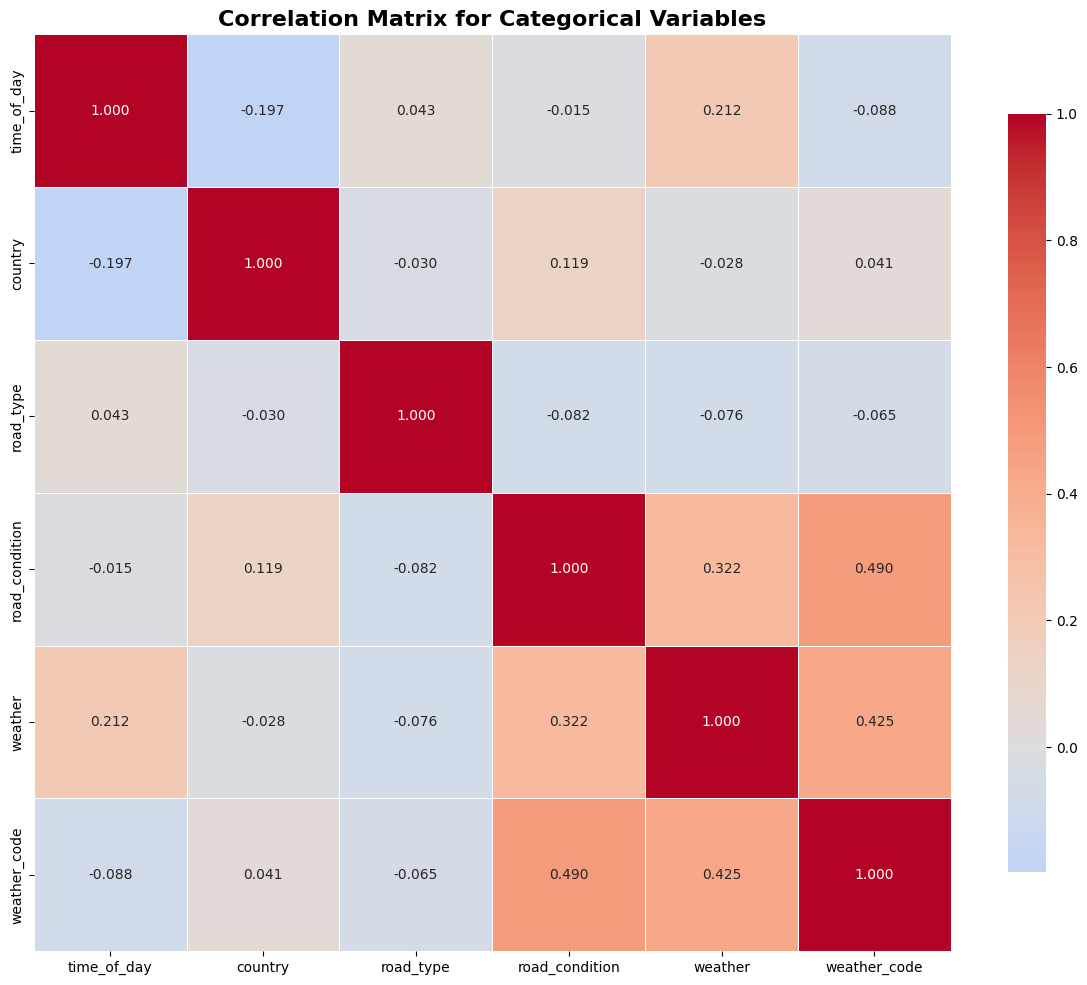

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5, fmt='.3f', cbar_kws={"shrink": .8})
plt.title("Correlation Matrix for Categorical Variables", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("./plots/categorical_correlation_matrix.png")
plt.show()

## Numerical Variables 

In [ ]:
print(f"Number of numerical features: {len(numeric_columns)}")
for col in numeric_columns:
    if col == 'coords':
        continue
    clean_data = data[col].dropna()
    print(f"\n{col.upper()}:")
    print(f"  Count: {len(clean_data)}")
    print(f"  Missing values: {data[col].isnull().sum()}")
    print(f"  Mean: {clean_data.mean():.3f}")
    print(f"  Median: {clean_data.median():.3f}")
    print(f"  Std: {clean_data.std():.3f}")
    print(f"  Min: {clean_data.min():.3f}")
    print(f"  Max: {clean_data.max():.3f}")
    print(f"  Range: {clean_data.max() - clean_data.min():.3f}")
    

Number of numerical features: 32

LAT:
  Count: 5998
  Missing values: 0
  Mean: 52.092
  Median: 52.228
  Std: 5.366
  Min: 41.794
  Max: 68.445
  Range: 26.651

LONG:
  Count: 5998
  Missing values: 0
  Mean: 12.522
  Median: 12.980
  Std: 5.227
  Min: -8.170
  Max: 23.491
  Range: 31.661

SOLAR_ANGLE_ELEVATION:
  Count: 5998
  Missing values: 0
  Mean: 22.782
  Median: 20.764
  Std: 23.300
  Min: -36.656
  Max: 64.865
  Range: 101.521

MONTH:
  Count: 5998
  Missing values: 0
  Mean: 6.306
  Median: 5.000
  Std: 3.082
  Min: 1.000
  Max: 12.000
  Range: 11.000

HOUR:
  Count: 5998
  Missing values: 0
  Mean: 12.573
  Median: 13.000
  Std: 3.898
  Min: 1.000
  Max: 22.000
  Range: 21.000

TEMPERATURE_2M:
  Count: 5985
  Missing values: 13
  Mean: 12.865
  Median: 12.024
  Std: 8.575
  Min: -18.748
  Max: 35.270
  Range: 54.018

RELATIVE_HUMIDITY_2M:
  Count: 5985
  Missing values: 13
  Mean: 70.120
  Median: 71.846
  Std: 15.829
  Min: 22.934
  Max: 100.000
  Range: 77.066

RAIN:
  C

Distribution

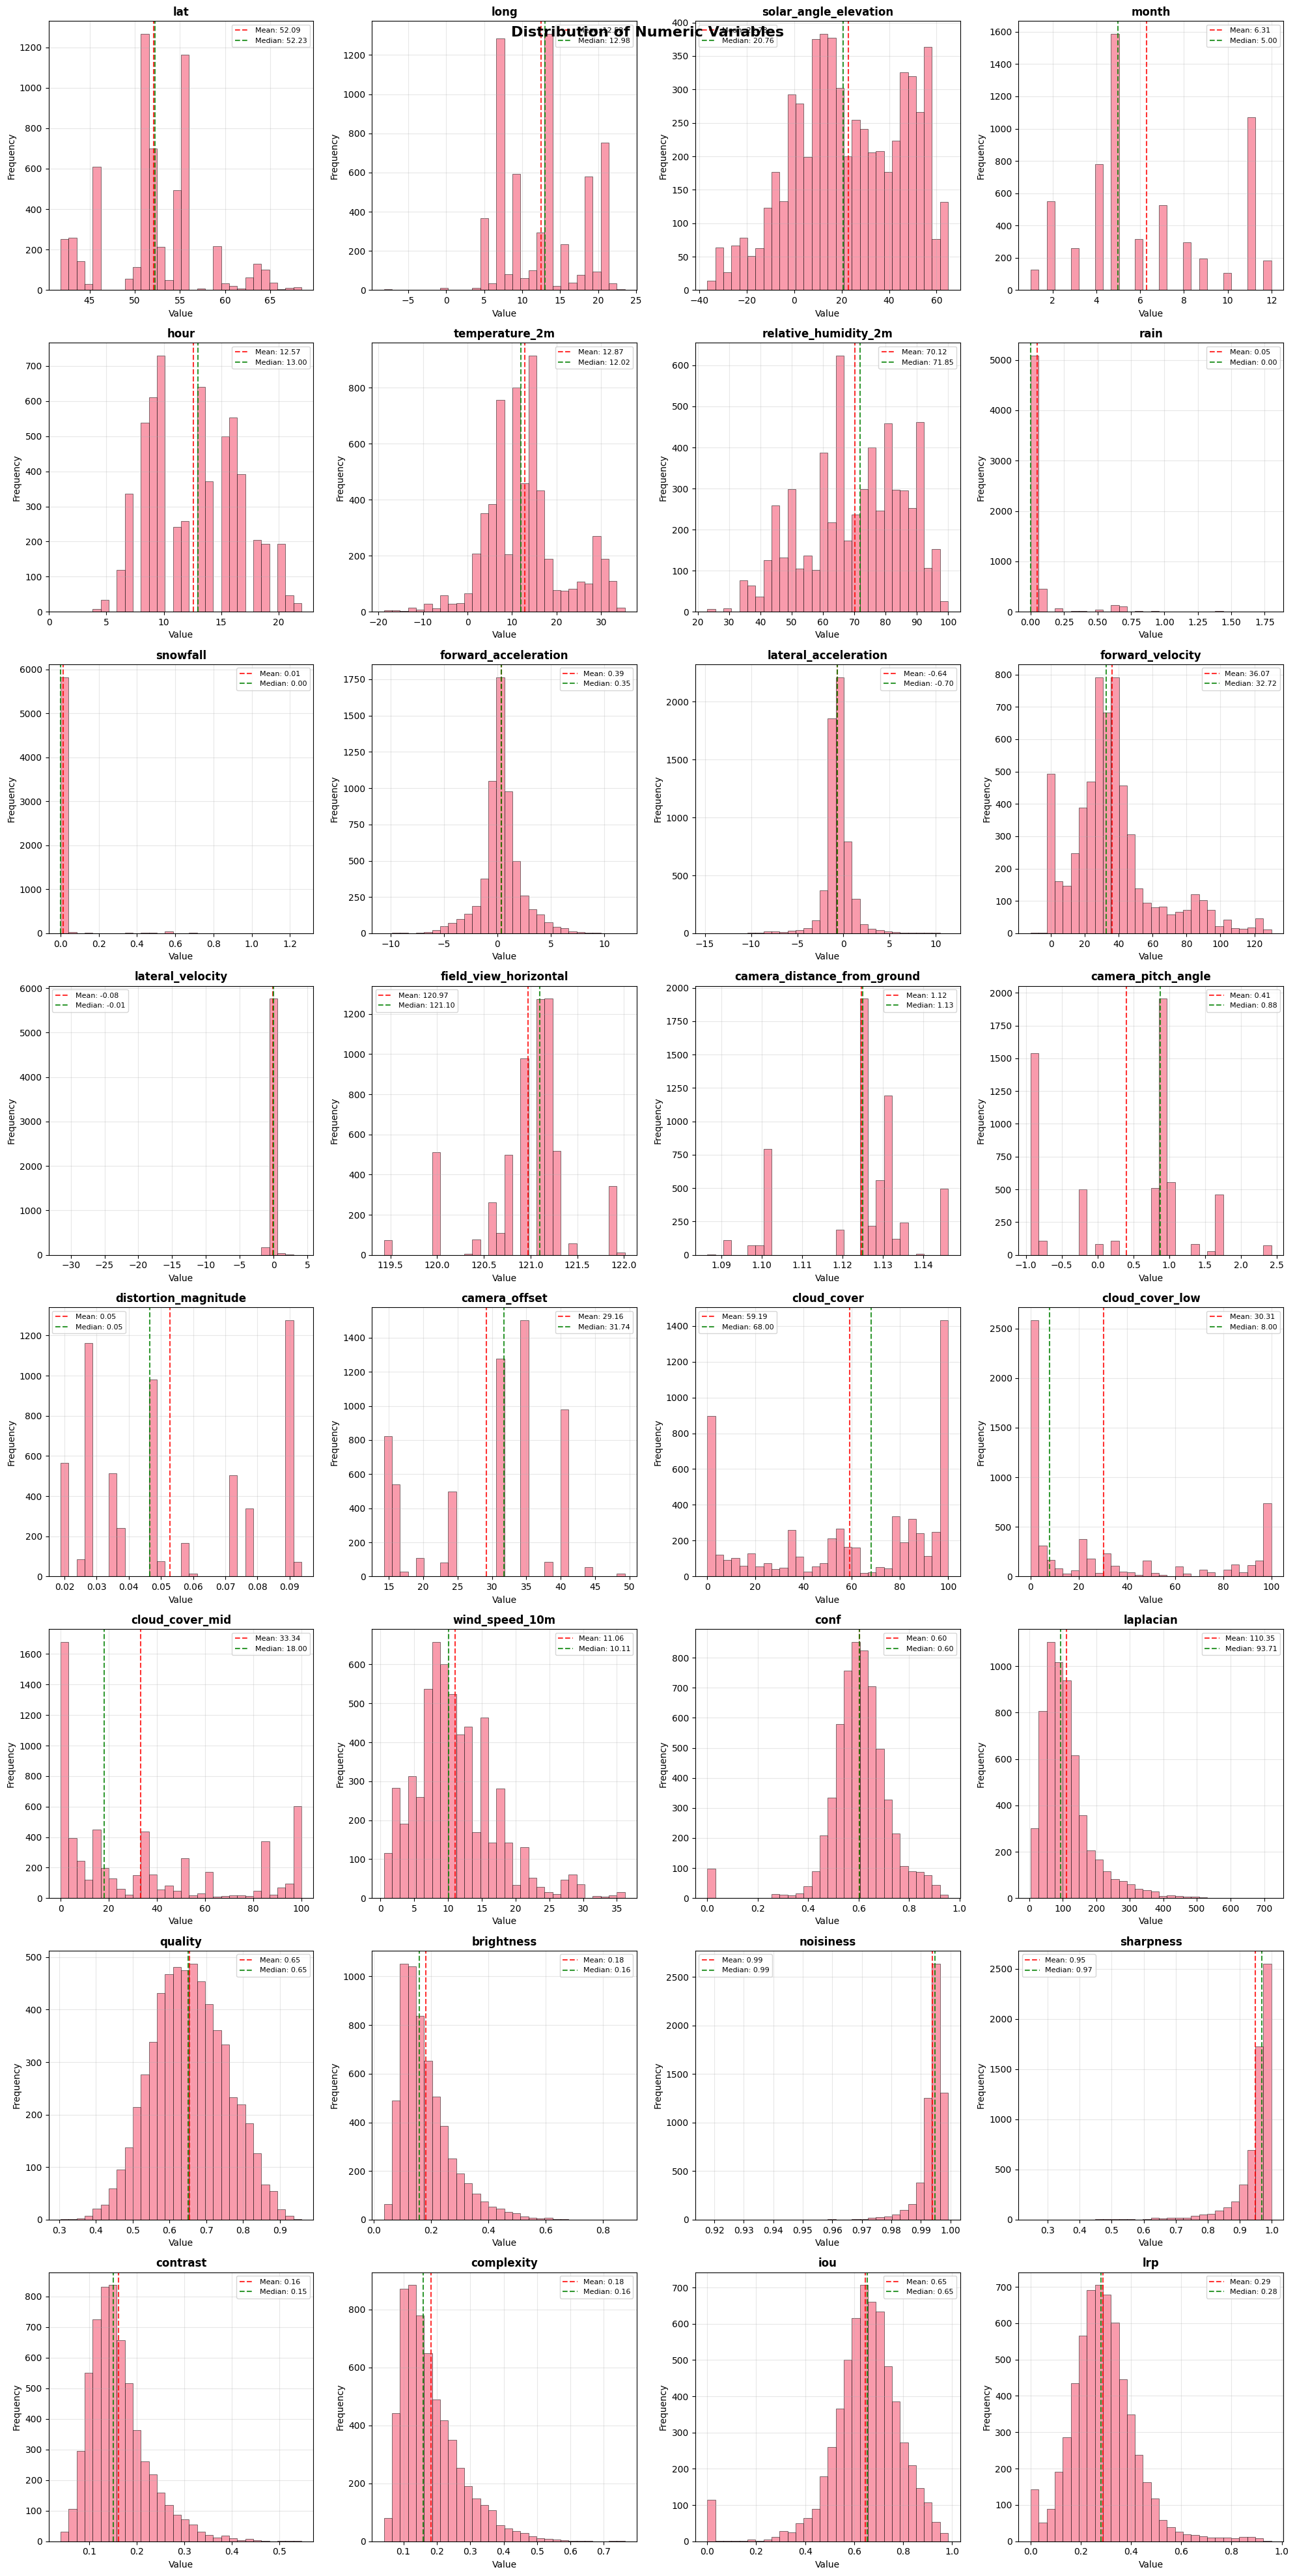

In [ ]:
n_cols = 4
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Distribution of Numeric Variables', fontsize=16, fontweight='bold')
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, column in enumerate(numeric_columns):
    if column == 'coords':
        continue
    clean_data = data[column].dropna()
    
    axes[i].hist(clean_data, bins=30, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{column}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    mean_val = clean_data.mean()
    median_val = clean_data.median()
    axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig("./plots/numeric_distributions.png")
plt.show()

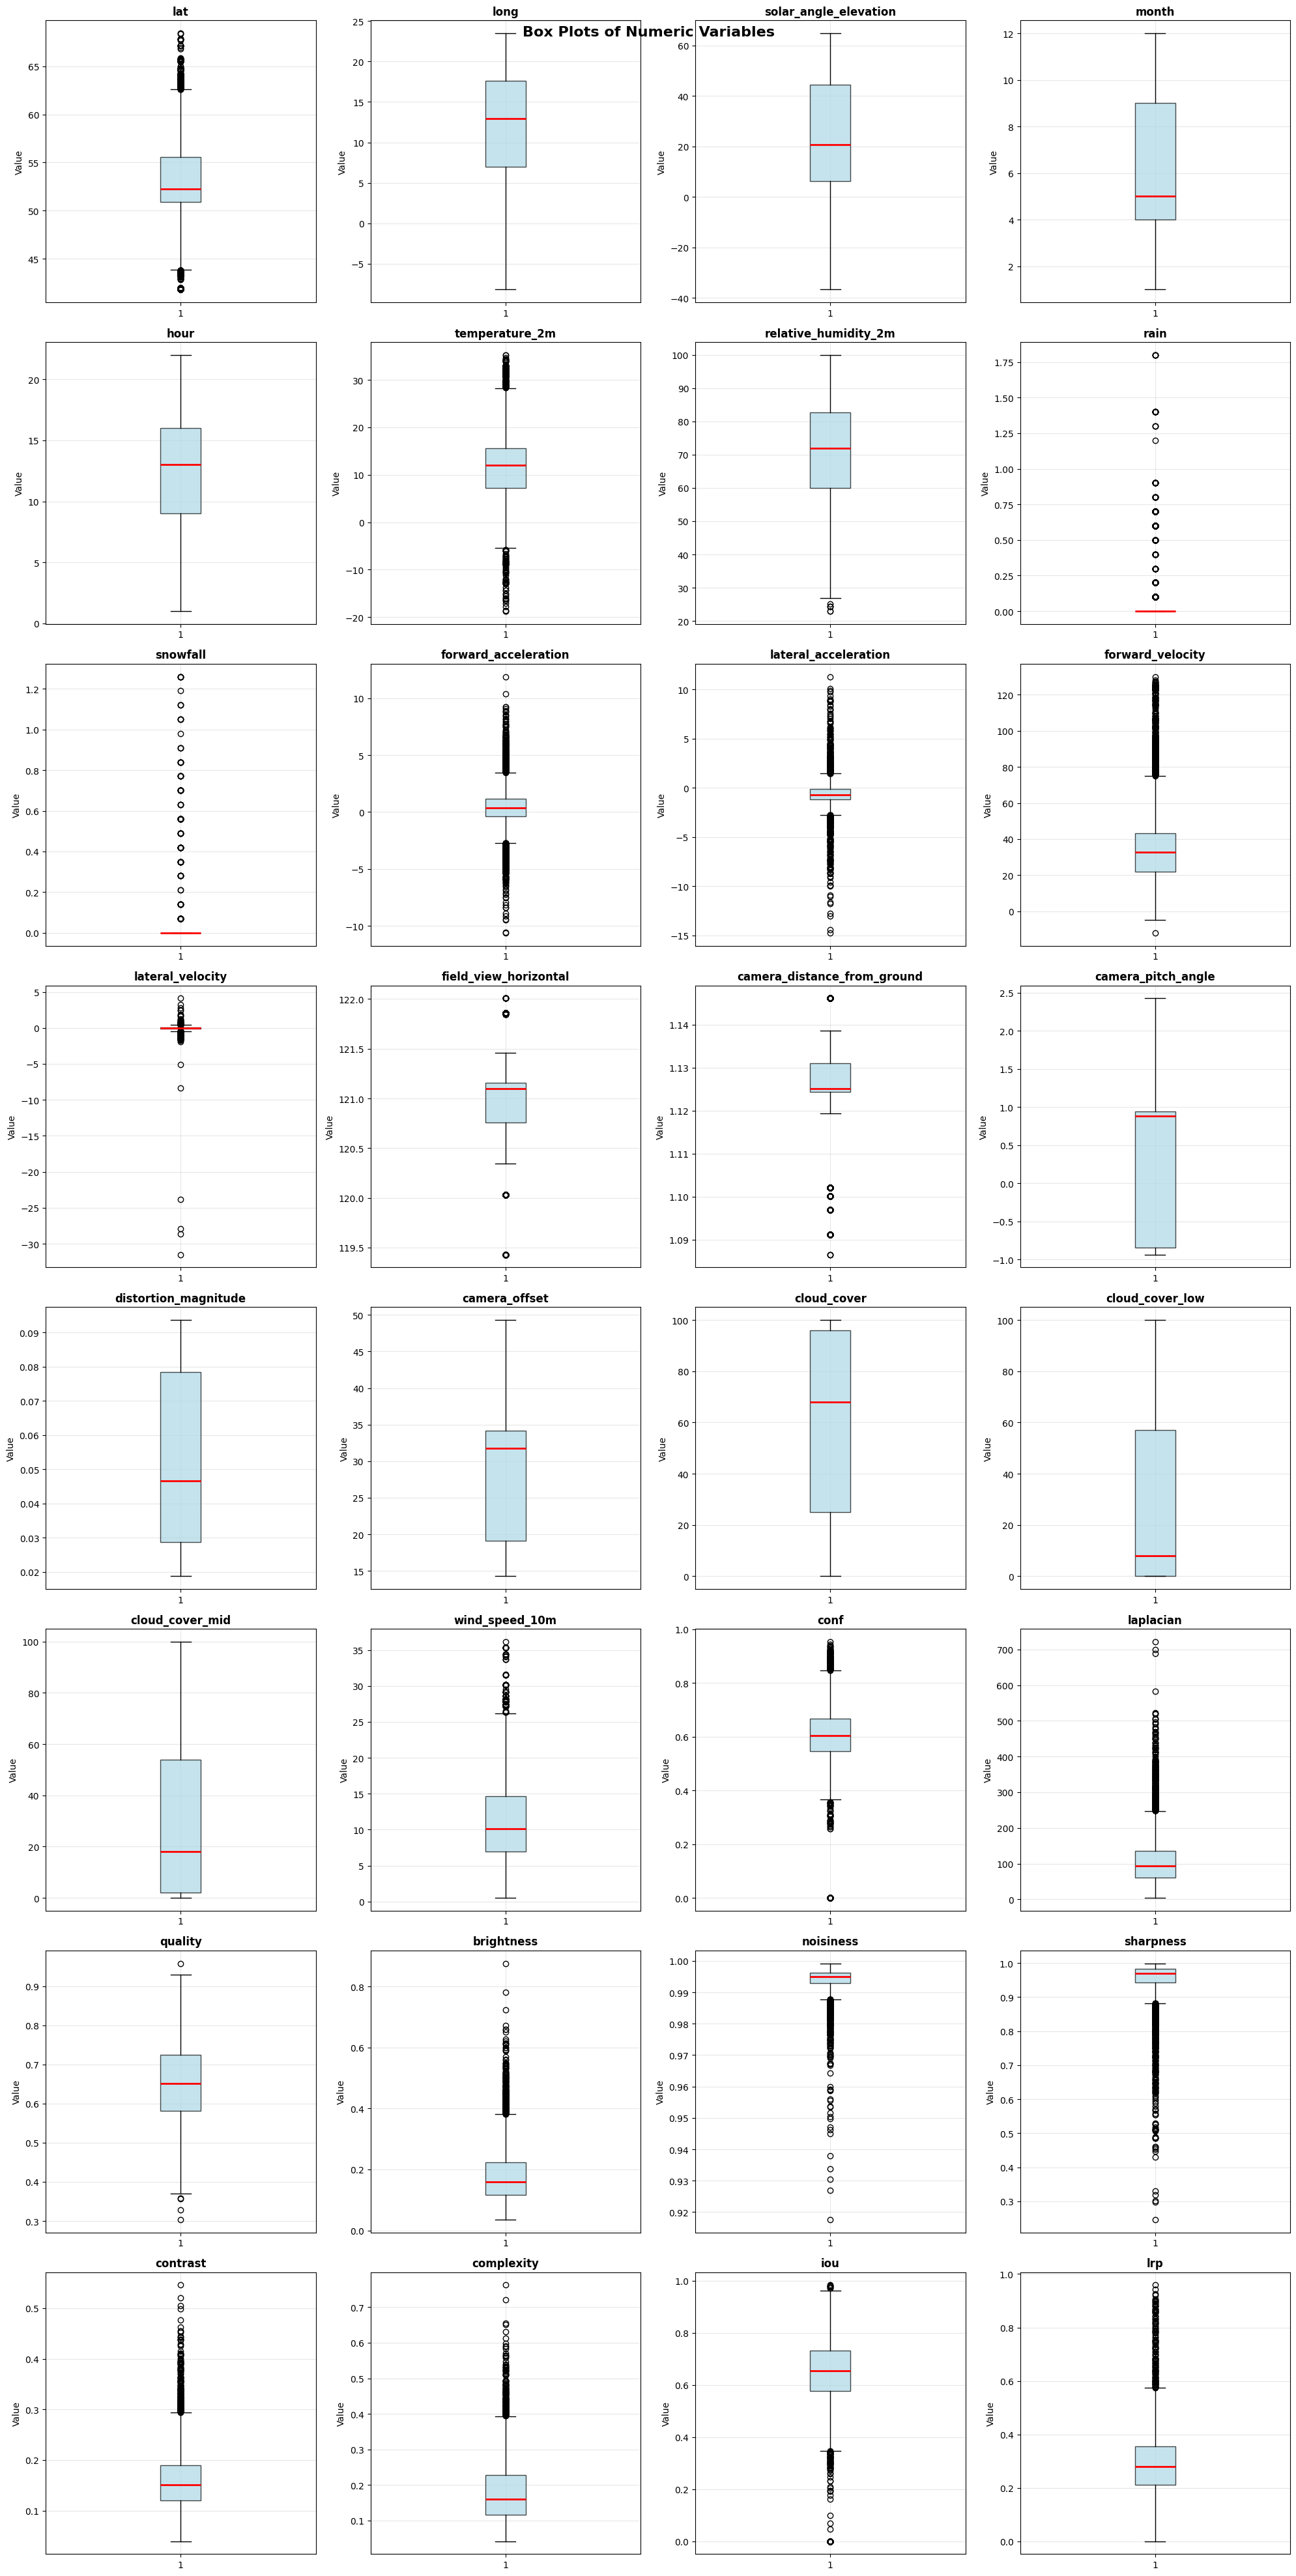

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Box Plots of Numeric Variables', fontsize=16, fontweight='bold')

axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, column in enumerate(numeric_columns):
    if column == 'coords':
        continue
    clean_data = data[column].dropna()
    
    # Create box plot
    axes[i].boxplot(clean_data, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{column}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


Correlation

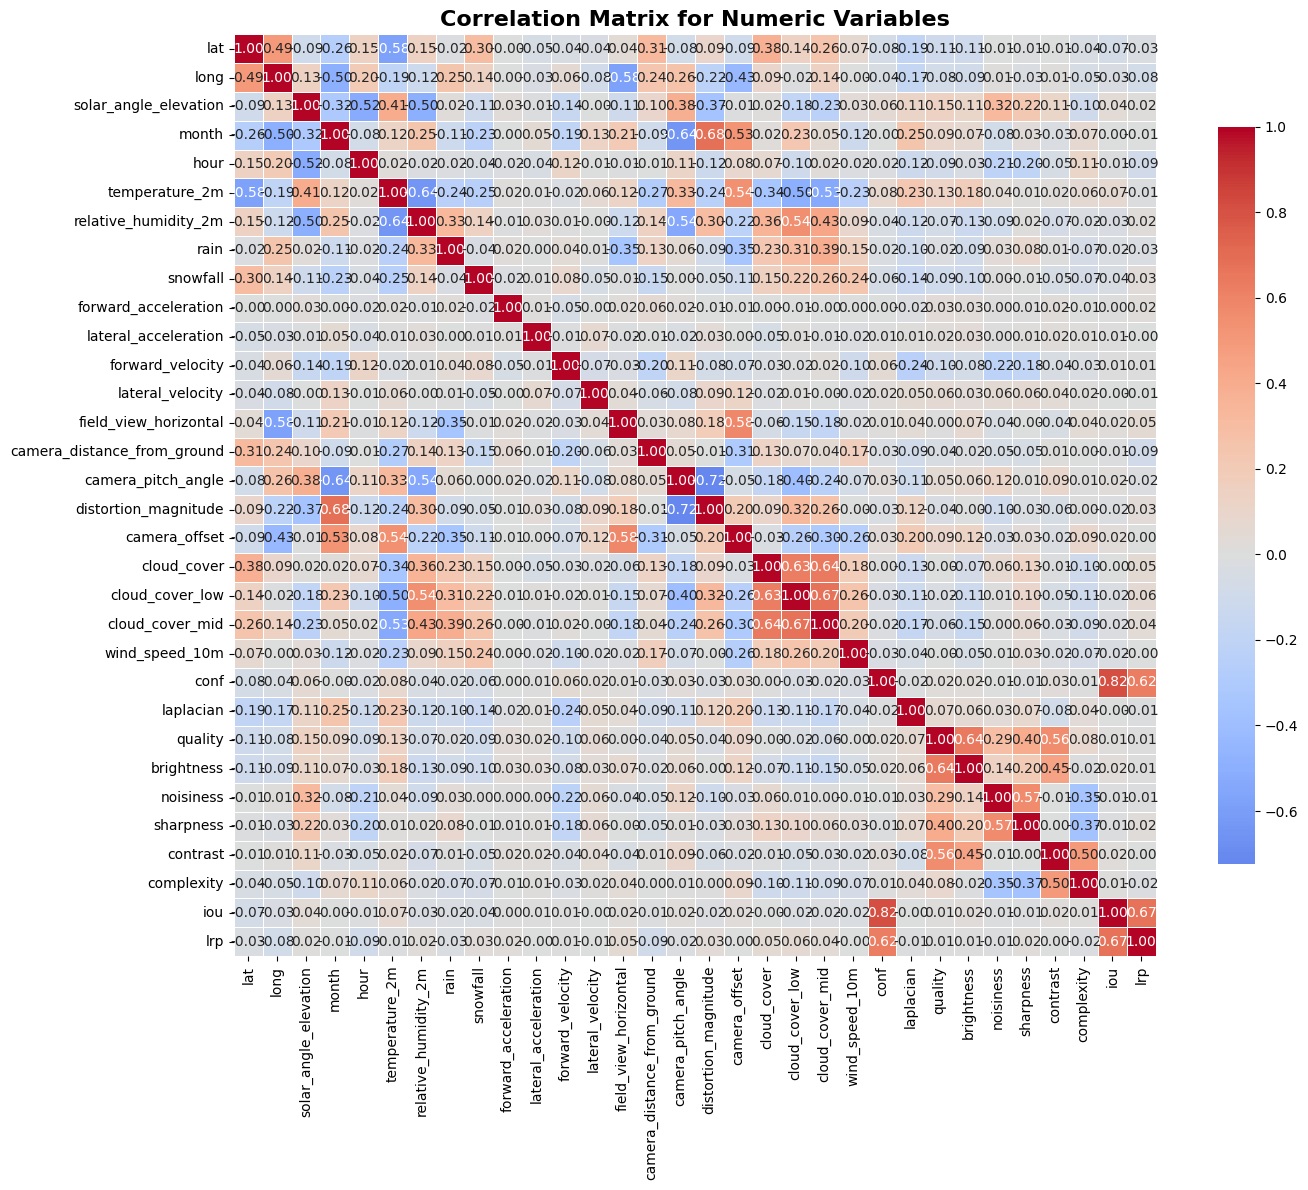

In [ ]:
numeric_data = data[numeric_columns].select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr('pearson')

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix for Numeric Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("./plots/numeric_correlation_matrix.png")
plt.show()

## Bivariate Correlation

Bivariate correlations between all these features and against the pass/fail result (success rate) for an instance

### Categorical Var

Use Etta-square for correlation between varaibles and IoU.
It measures the proportion of variance associated with each main effect and interaction effect in an ANOVA model.

In [ ]:
def compute_cat_correlations(data, categorical_columns, target_column='iou'):
    categorical_correlations = []

    for col in categorical_columns:
        categories = data[col].unique()
        groups = [data[data[col] == cat][target_column].values for cat in categories]
        groups = [group for group in groups if len(group) > 0]  
        
        if len(groups) >= 2:
            overall_mean = data[target_column].mean()
            ssb = sum(len(group) * (np.mean(group) - overall_mean)**2 for group in groups)
            sst = sum((data[target_column] - overall_mean)**2)
            eta_squared = ssb / sst if sst != 0 else 0
            categorical_correlations.append({'col': col,'Eta_Squared': eta_squared,})

    categorical_corr_df = pd.DataFrame(categorical_correlations)
    categorical_corr_df = categorical_corr_df.sort_values('Eta_Squared', ascending=False)
    return categorical_corr_df

In [ ]:
categorical_iou_corr_df = compute_cat_correlations(data, categorical_columns, target_column='iou')
categorical_lrp_corr_df = compute_cat_correlations(data, categorical_columns, target_column='lrp')

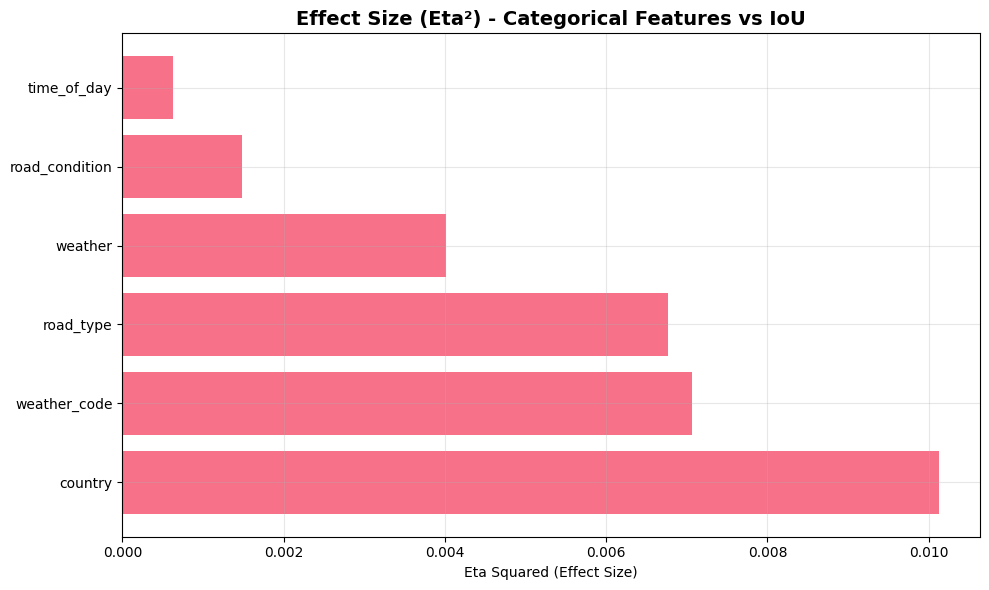

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(categorical_iou_corr_df['col'], categorical_iou_corr_df['Eta_Squared'])
plt.title('Effect Size (Eta²) - Categorical Features vs IoU', fontsize=14, fontweight='bold')
plt.xlabel('Eta Squared (Effect Size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/categorical_iou_effect_size.png")
plt.show()

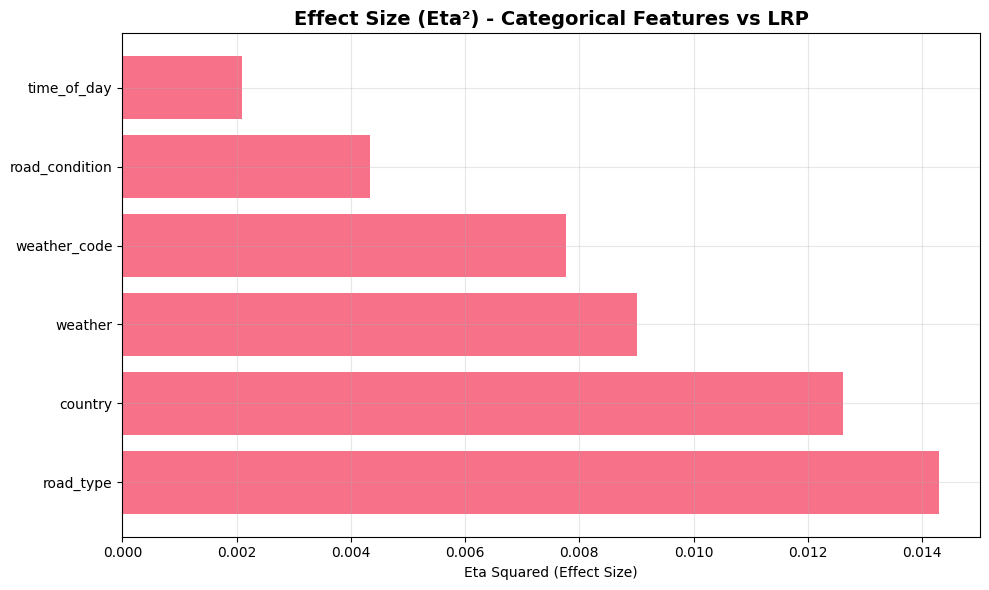

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(categorical_lrp_corr_df['col'], categorical_lrp_corr_df['Eta_Squared'])
plt.title('Effect Size (Eta²) - Categorical Features vs LRP', fontsize=14, fontweight='bold')
plt.xlabel('Eta Squared (Effect Size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/categorical_lrp_effect_size.png")
plt.show()

## Numerical Var

Plots relationship between variables and IoU using both Pearson and Spearman correlation. 

In [ ]:
def compute_num_correlations(data, numeric_columns, target_column='iou'):
    numeric_correlations = []

    for col in numeric_columns:
        if col == "coords" or col == "iou" or col == "pq" or col == "lrp":
            continue
        pearson_corr, pearson_p = pearsonr(data[col], data[target_column])
        spearman_corr, spearman_p = spearmanr(data[col], data[target_column])
        
        numeric_correlations.append({
            'col': col,
            'Pearson_Corr': pearson_corr,
            'Spearman_Corr': spearman_corr,
        })

    numeric_corr_df = pd.DataFrame(numeric_correlations)
    numeric_corr_df = numeric_corr_df.sort_values('Pearson_Corr', key=abs, ascending=False)
    return numeric_corr_df

In [ ]:
numeric_corr_df_iou = compute_num_correlations(data, numeric_columns, target_column='iou')
numeric_corr_df_lrp = compute_num_correlations(data, numeric_columns, target_column='lrp')


<Figure size 640x480 with 0 Axes>

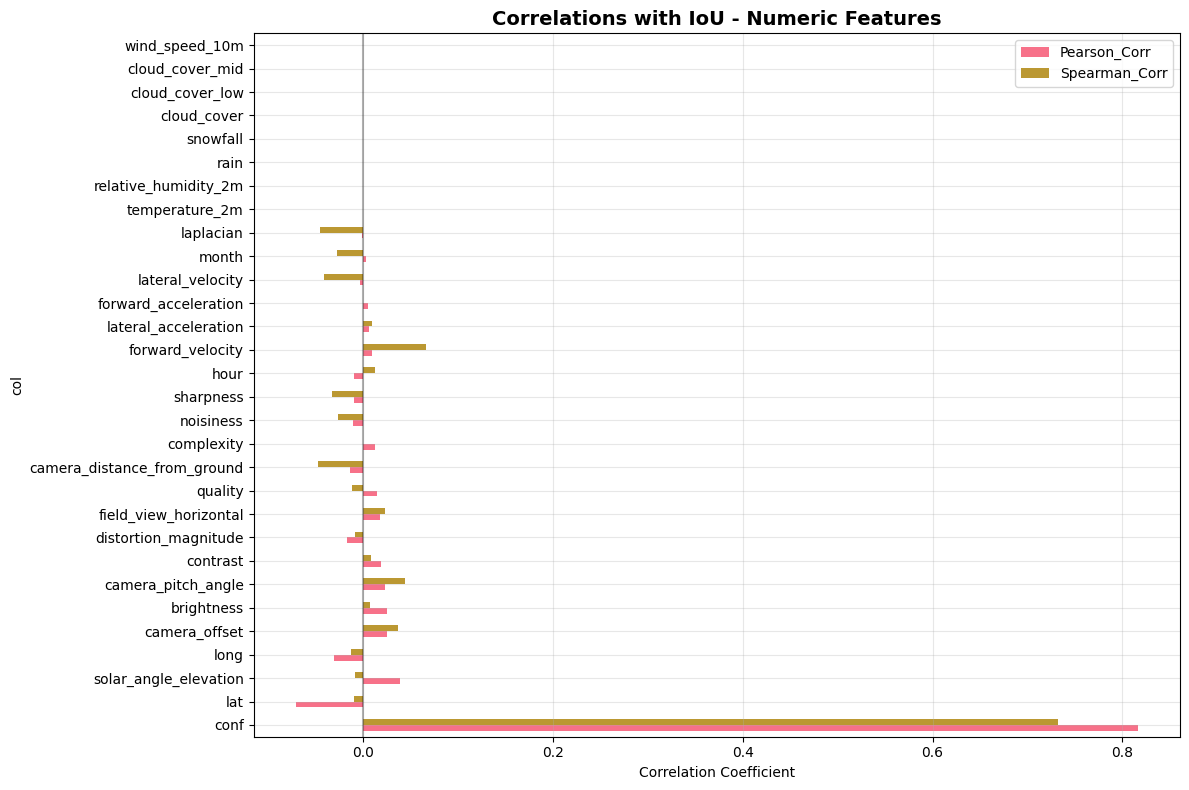

In [ ]:
plt.figure()
correlations_plot = numeric_corr_df_iou.set_index('col')[['Pearson_Corr', 'Spearman_Corr']]
correlations_plot.plot(kind='barh', figsize=(12, 8))
plt.title('Correlations with IoU - Numeric Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/numeric_iou_correlations.png")
plt.show()

<Figure size 640x480 with 0 Axes>

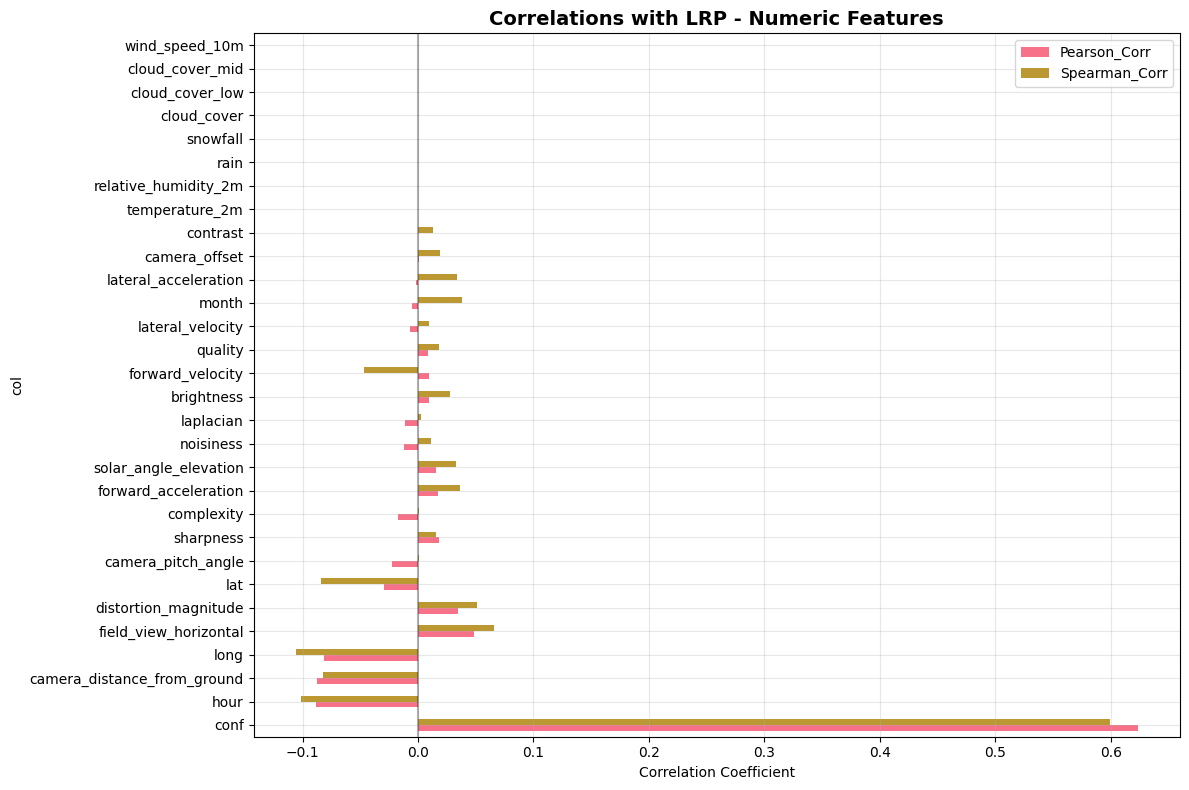

In [ ]:
plt.figure()
correlations_plot = numeric_corr_df_lrp.set_index('col')[['Pearson_Corr', 'Spearman_Corr']]
correlations_plot.plot(kind='barh', figsize=(12, 8))
plt.title('Correlations with LRP - Numeric Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/numeric_lrp_correlations.png")
plt.show()

# Characteristic Curves

Success rate (IoU) vs Relevant or Irrelevant feature. Try this for both. Are of curve = capability. Also Black dashed line is added to show the linear regression for the black points (pass/fail). 

The conformances (Spearman correlations against monotonic sequence) are 0.80, 0.60, 1.00 and −0.50, respectively. Dont completly understand this.

# Agent Characteristic Grids

Placing each feature as a dimension and the success rate (or other performance metric) represented in colours (or shade of grey).
https://scikit-learn.org/stable/modules/partial_dependence.html

In [ ]:
def zscore(series):
    std = series.std(ddof=0)
    return (series - series.mean()) / std if std else series * 0.0

def make_bins(series, n_bins=5):
    edges = np.unique(np.quantile(series, np.linspace(0, 1, n_bins + 1)))
    if len(edges) <= 2:
        edges = np.linspace(series.min(), series.max(), n_bins + 1)
    edges[0] -= 1e-6
    edges[-1] += 1e-6
    return edges

In [ ]:
def summarise_agent_grid(df, reward_size_bins, reward_distance_bins, distance_index, size_index, agent=None):
    subset = df if agent is None else df[df["agent"] == agent]
    if subset.empty:
        return None, None, np.nan

    binned = subset.assign(
        reward_size_bin=pd.cut(subset["reward_size"], bins=reward_size_bins, include_lowest=True),
        reward_distance_bin=pd.cut(subset["reward_distance"], bins=reward_distance_bins, include_lowest=True),
    )

    summary = (
        binned.groupby(["reward_distance_bin", "reward_size_bin"], observed=False)
              .agg(success_rate=("success", "mean"),
                   count=("success", "size"))
    )

    rate = (summary["success_rate"]
            .unstack("reward_size_bin")
            .reindex(index=distance_index, columns=size_index))
    count = (summary["count"]
             .unstack("reward_size_bin")
             .reindex(index=distance_index, columns=size_index)
             .fillna(0))

    capability = subset["success"].mean()
    return rate, count, capability

def draw_agent_grid(ax, rate, count, capability, title, count_max, size_labels, distance_labels):
    success_cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
    count_cmap = plt.cm.Greys

    if rate is None:
        ax.axis("off")
        ax.set_title(f"{title} (no data)")
        return None

    rate_values = rate.to_numpy()
    count_values = count.to_numpy()
    hm = ax.imshow(np.ma.masked_invalid(rate_values), cmap=success_cmap, vmin=0, vmax=1, origin="lower")

    if count_max > 0:
        ax.imshow(Normalize(vmin=0, vmax=count_max)(count_values),
                  cmap=count_cmap, origin="lower", alpha=0.35)

    for (i, j), cnt in np.ndenumerate(count_values):
        if np.isnan(rate_values[i, j]):
            continue
        ax.text(j, i, f"{int(cnt)}\n{rate_values[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=8)

    ax.set_xticks(np.arange(len(size_labels)))
    ax.set_xticklabels(size_labels, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(distance_labels)))
    ax.set_yticklabels(distance_labels)
    ax.set_xlim(-0.5, len(size_labels) - 0.5)
    ax.set_ylim(-0.5, len(distance_labels) - 0.5)
    ax.set_xlabel("reward_size (z-score)")
    ax.set_ylabel("reward_distance (z-score)")
    ax.set_title(f"{title}\nCapability: {capability:.3f}")
    ax.set_xticks(np.arange(-0.5, len(size_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(distance_labels), 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    return hm

In [ ]:
agent_column = "weather"   
reward_size_source = "hour" 
reward_distance_source = "contrast"
y_pos_source = "lat"
success_metric = "iou"
success_threshold = 0.5           

agent_df = (data[[agent_column, reward_size_source, reward_distance_source, y_pos_source, success_metric]].dropna().rename(columns={agent_column: "agent",reward_size_source: "reward_size",reward_distance_source: "reward_distance",y_pos_source: "y_pos",success_metric: "metric_value",}))

agent_df["reward_size"] = zscore(agent_df["reward_size"])
agent_df["reward_distance"] = zscore(agent_df["reward_distance"])
agent_df["y_pos"] = zscore(agent_df["y_pos"])
agent_df["success"] = (agent_df.pop("metric_value") >= success_threshold).astype(int)
agent_df = agent_df[["agent", "reward_size", "reward_distance", "y_pos", "success"]]

print(agent_df.head())

                        agent  reward_size  reward_distance     y_pos  success
Unnamed: 0                                                                    
8459                   cloudy     0.366080        -0.513216  0.654598        1
71801               clear-day     1.135708        -0.009240 -1.883414        1
90649       partly-cloudy-day     0.622623        -0.416239 -0.542363        1
48806       partly-cloudy-day     1.135708         0.042432  0.649477        1
35874               clear-day    -0.916633         1.527374 -1.232664        1


/home/felix/miniconda3/envs/predictable-ad/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


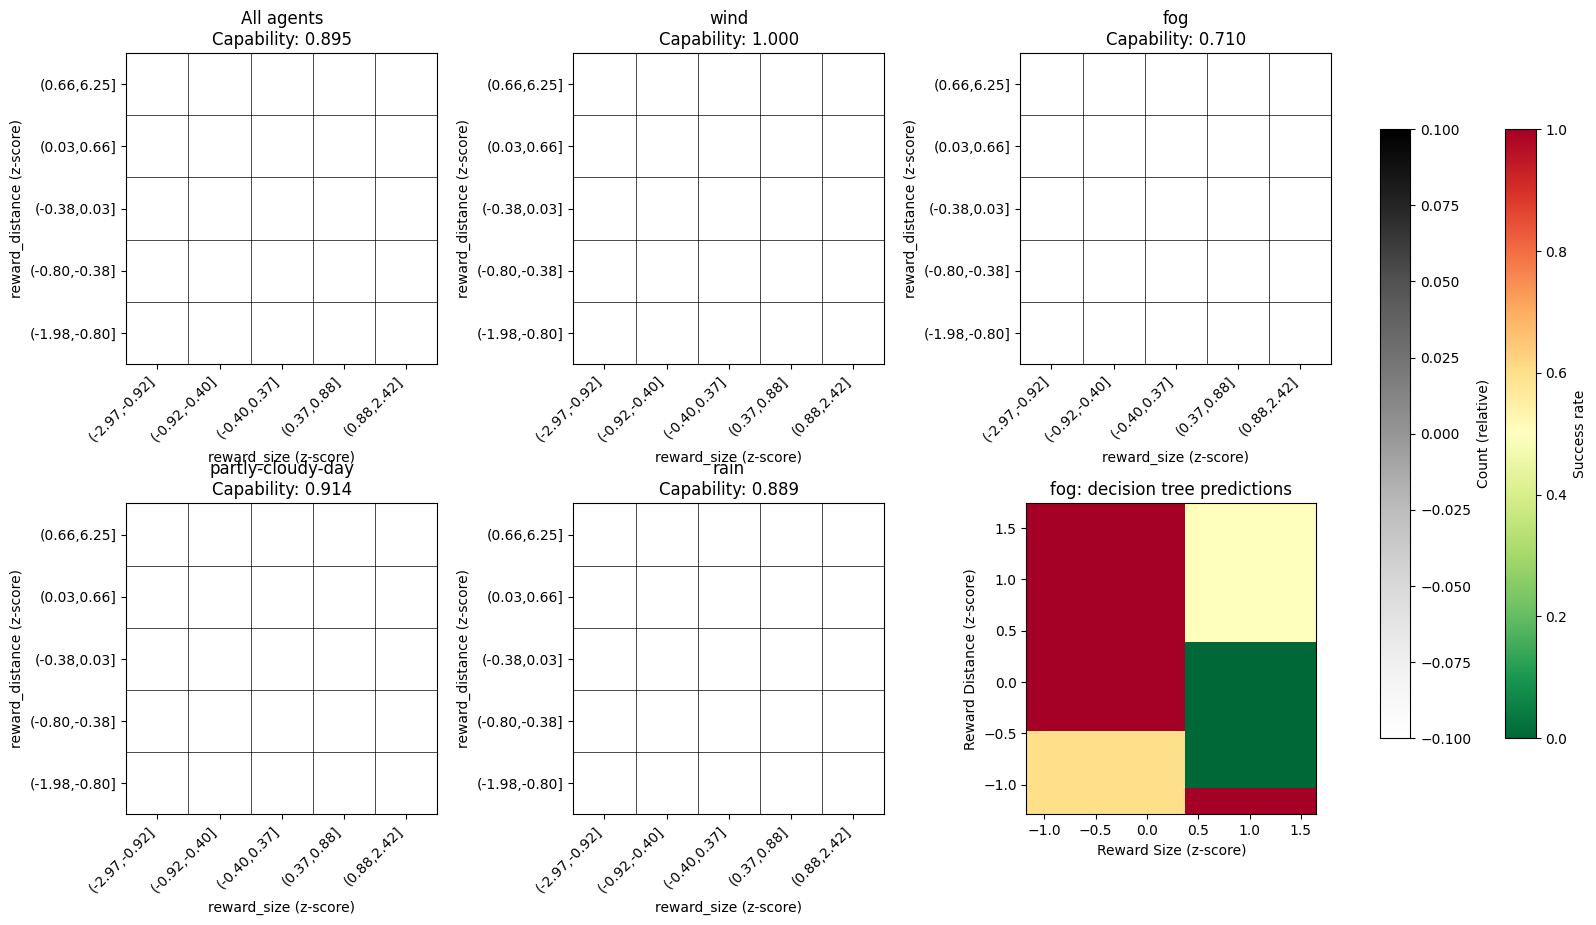

In [ ]:
reward_size_bins = make_bins(agent_df["reward_size"])
reward_distance_bins = make_bins(agent_df["reward_distance"])
size_index = pd.IntervalIndex.from_breaks(reward_size_bins, closed="right")
distance_index = pd.IntervalIndex.from_breaks(reward_distance_bins, closed="right")
size_labels = [f"({iv.left:.2f},{iv.right:.2f}]" for iv in size_index]
distance_labels = [f"({iv.left:.2f},{iv.right:.2f}]" for iv in distance_index]

agent_success = agent_df.groupby("agent")["success"].mean()
agent_counts = agent_df["agent"].value_counts()

success_cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
count_cmap = plt.cm.Greys

candidate_order = []
for candidate in [
    agent_success.idxmax(),
    agent_success.idxmin(),
    agent_counts.idxmax(),
    agent_success.sort_values().index[len(agent_success) // 2],
]:
    if candidate not in candidate_order:
        candidate_order.append(candidate)
for agent in agent_counts.index:
    if len(candidate_order) >= 4:
        break
    if agent not in candidate_order:
        candidate_order.append(agent)

agents_to_plot = [(None, "All agents")]
agents_to_plot.extend((agent, agent) for agent in candidate_order[:4])

summaries = [(*summarise_agent_grid(agent_df, reward_size_bins, reward_distance_bins, distance_index, size_index, agent=name), label)
             for name, label in agents_to_plot]
count_max = max((cnt.to_numpy().max() for _, cnt, _, _ in summaries if cnt is not None), default=1)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
axes_flat = axes.flatten()
heatmaps = []

for idx, (rate, cnt, capability, label) in enumerate(summaries[:len(axes_flat) - 1]):
    hm = draw_agent_grid(axes_flat[idx], rate, cnt, capability, label, count_max, size_labels, distance_labels)
    if hm is not None:
        heatmaps.append(hm)

used = min(len(summaries), len(axes_flat) - 1)
for ax in axes_flat[used:-1]:
    ax.axis("off")

if heatmaps:
    fig.colorbar(heatmaps[0], ax=axes_flat[:-1], shrink=0.8, pad=0.01).set_label("Success rate")
count_mapper = ScalarMappable(norm=Normalize(vmin=0, vmax=count_max), cmap=count_cmap)
count_mapper.set_array([])
fig.colorbar(count_mapper, ax=axes_flat[:-1], shrink=0.8, pad=0.04).set_label("Count (relative)")

tree_ax = axes_flat[-1]
target_agent = agent_success.idxmin()
subset = agent_df[agent_df["agent"] == target_agent]

if subset.shape[0] < 5 or subset["success"].nunique() <= 1:
    tree_ax.axis("off")
    tree_ax.set_title(f"{target_agent}: not enough variation")
else:
    feature_cols = ["reward_size", "reward_distance", "y_pos"]
    tree = DecisionTreeRegressor(max_depth=3, random_state=SEED)
    tree.fit(subset[feature_cols], subset["success"])

    rs_vals = np.linspace(subset["reward_size"].min(), subset["reward_size"].max(), 60)
    rd_vals = np.linspace(subset["reward_distance"].min(), subset["reward_distance"].max(), 60)

    if np.isclose(rs_vals[0], rs_vals[-1]) or np.isclose(rd_vals[0], rd_vals[-1]):
        tree_ax.axis("off")
        tree_ax.set_title(f"{target_agent}: feature spread too small")
    else:
        mesh_rs, mesh_rd = np.meshgrid(rs_vals, rd_vals)
        grid_features = np.column_stack([
            mesh_rs.ravel(),
            mesh_rd.ravel(),
            np.full(mesh_rs.size, subset["y_pos"].median()),
        ])
        pred_success = tree.predict(grid_features).reshape(mesh_rs.shape)

        tree_ax.imshow(
            pred_success,
            cmap=success_cmap,
            origin="lower",
            extent=[rs_vals.min(), rs_vals.max(), rd_vals.min(), rd_vals.max()],
            vmin=0,
            vmax=1,
        )
        tree_ax.set_xlabel("Reward Size (z-score)")
        tree_ax.set_ylabel("Reward Distance (z-score)")
        tree_ax.set_title(f"{target_agent}: decision tree predictions")

plt.show()
